In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("diamonds.csv")
df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
diamond_df = df.copy()
diamond_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
diamond_df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
diamond_df.shape

(53940, 10)

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Apply the outlier removal for each numerical column identified earlier
numerical_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
diamond_df_cleaned = diamond_df.copy()

print(f"Original shape: {diamond_df_cleaned.shape}")

for col in numerical_cols:
    initial_rows = diamond_df_cleaned.shape[0]
    diamond_df_cleaned = remove_outliers_iqr(diamond_df_cleaned, col)
    removed_rows = initial_rows - diamond_df_cleaned.shape[0]
    if removed_rows > 0:
        print(f"Removed {removed_rows} outliers from '{col}' using IQR method.")

print(f"New shape after outlier removal: {diamond_df_cleaned.shape}")

display(diamond_df_cleaned.head())

Original shape: (53940, 10)
Removed 1889 outliers from 'carat' using IQR method.
Removed 2796 outliers from 'depth' using IQR method.
Removed 342 outliers from 'table' using IQR method.
Removed 2368 outliers from 'price' using IQR method.
Removed 4 outliers from 'x' using IQR method.
Removed 1 outliers from 'y' using IQR method.
Removed 8 outliers from 'z' using IQR method.
New shape after outlier removal: (46532, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48


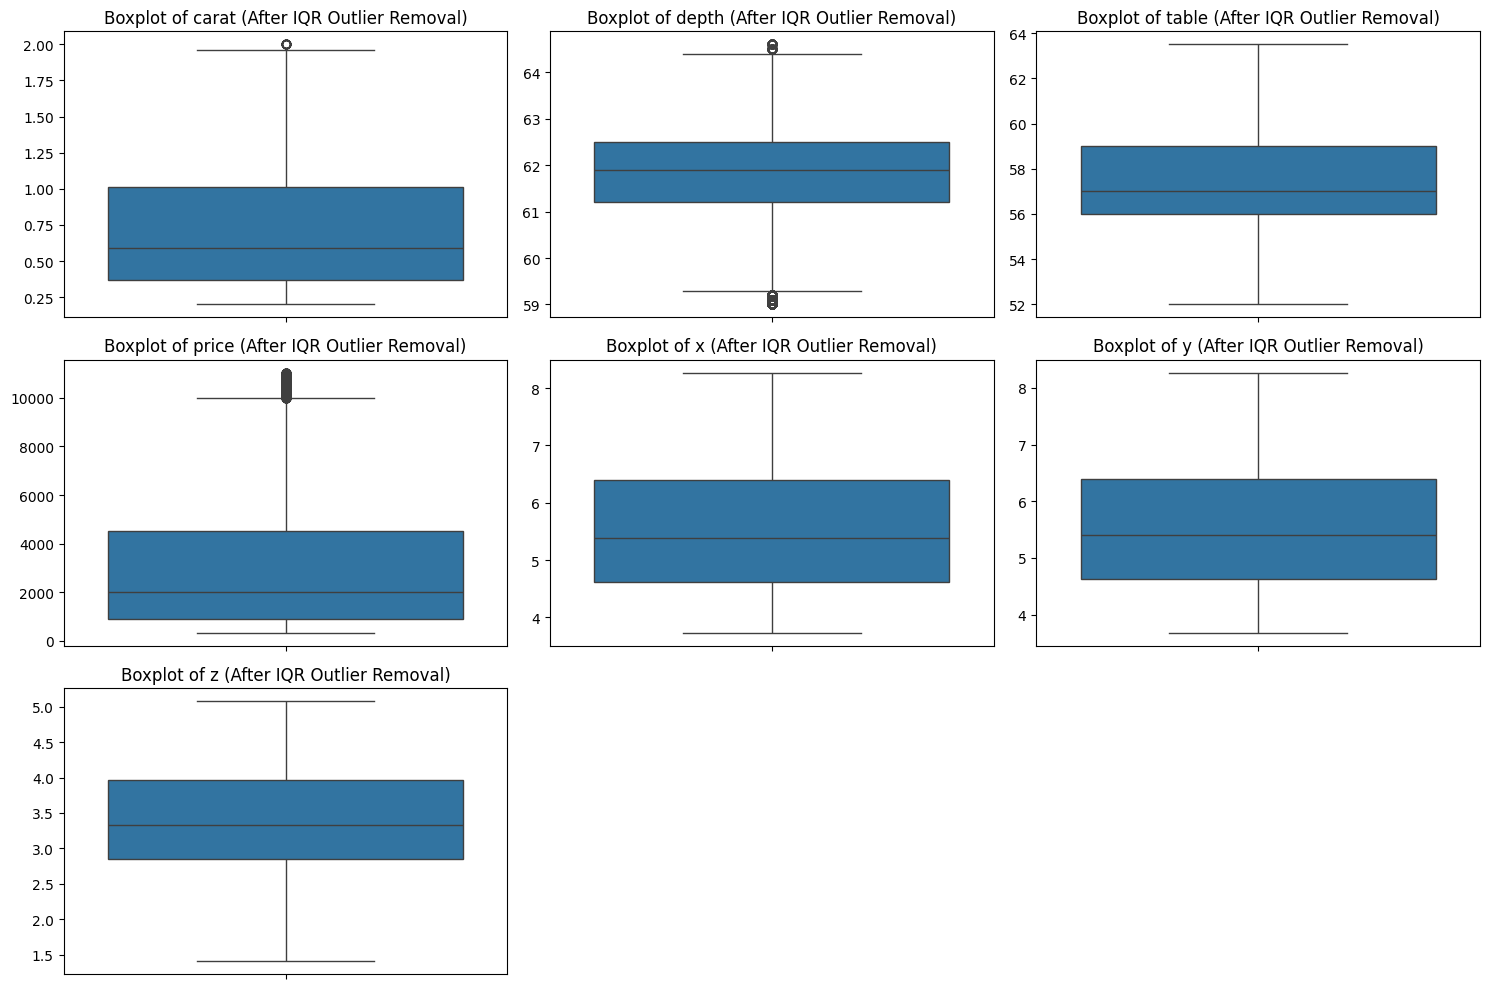

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the numerical columns again after outlier removal
numerical_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=diamond_df_cleaned[col])
    plt.title(f'Boxplot of {col} (After IQR Outlier Removal)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

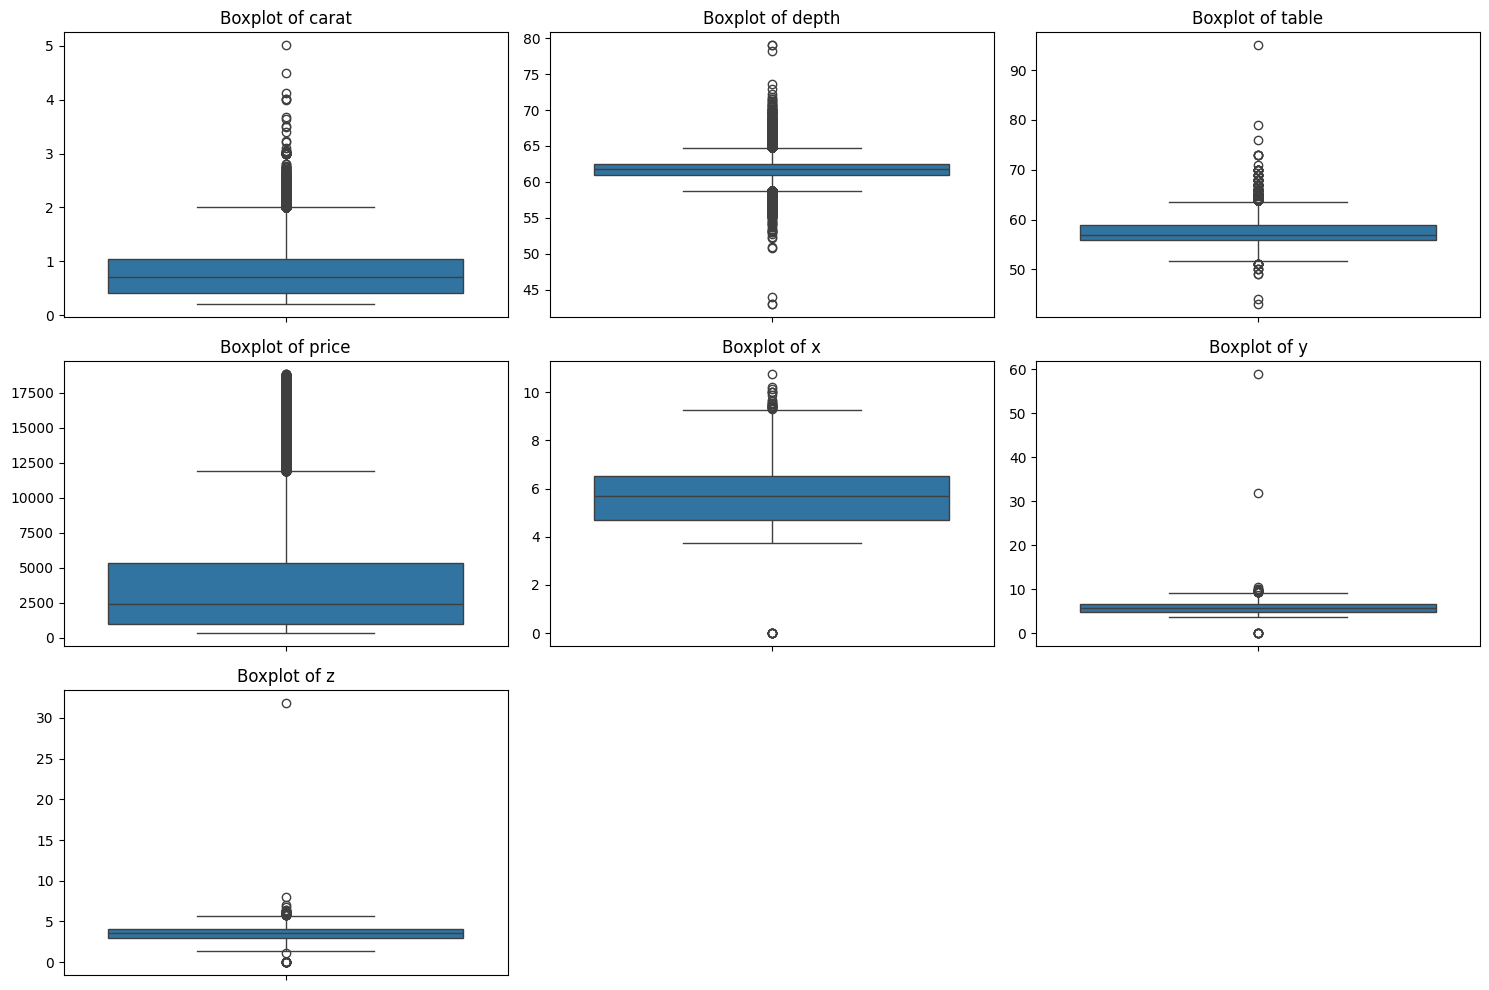

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier visualization
numerical_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

# Create subplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)  # Adjust grid size if more columns are added
    sns.boxplot(y=diamond_df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical columns
le_cut = LabelEncoder()
le_color = LabelEncoder()
le_clarity = LabelEncoder()

diamond_df_cleaned['cut'] = le_cut.fit_transform(diamond_df_cleaned['cut'])
diamond_df_cleaned['color'] = le_color.fit_transform(diamond_df_cleaned['color'])
diamond_df_cleaned['clarity'] = le_clarity.fit_transform(diamond_df_cleaned['clarity'])

diamond_df_cleaned.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,6,7,62.8,57.0,336,3.94,3.96,2.48


In [ ]:
X = diamond_df_cleaned.drop("price", axis=1)
y = diamond_df_cleaned["price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (46532, 9)
Target shape: (46532,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

import numpy as np

In [ ]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [ ]:
splits = [0.1, 0.2, 0.3, 0.4]

In [ ]:
results = []

best_r2 = -999
best_model = None
best_model_name = ""
best_split = None

for split in splits:

    print(f"\n===== Split {int(split*100)}:{int((1-split)*100)} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append([name, split, r2, mae, rmse])

        print(f"{name}")
        print("R2  :", r2)
        print("MAE :", mae)
        print("RMSE:", rmse)
        print("------------------------")

        # cek model terbaik
        if r2 > best_r2:
            best_r2 = r2
            best_model = model
            best_model_name = name
            best_split = split


===== Split 10:90 =====
Random Forest
R2  : 0.9837824603949362
MAE : 188.16897695019134
RMSE: 336.95491587077765
------------------------
XGBoost
R2  : 0.9841281771659851
MAE : 195.7982635498047
RMSE: 333.3442172702265
------------------------
KNN
R2  : 0.9531066138990735
MAE : 335.22350666093683
RMSE: 572.9742567664455
------------------------

===== Split 20:80 =====
Random Forest
R2  : 0.9823413123408886
MAE : 192.27263439576973
RMSE: 344.86579773084935
------------------------
XGBoost
R2  : 0.9834058284759521
MAE : 194.1949462890625
RMSE: 334.3096080918106
------------------------
KNN
R2  : 0.9476674156451558
MAE : 348.8485870849898
RMSE: 593.6862678621717
------------------------

===== Split 30:70 =====
Random Forest
R2  : 0.9816506759668259
MAE : 196.0473381753991
RMSE: 352.629719372742
------------------------
XGBoost
R2  : 0.982782244682312
MAE : 198.49400329589844
RMSE: 341.58378822040135
------------------------
KNN
R2  : 0.9437728365201941
MAE : 363.3759025787965
RMSE: 617

<Figure size 800x600 with 0 Axes>

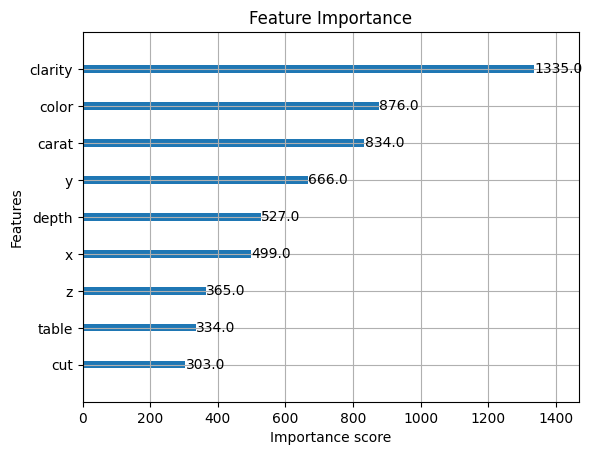

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(best_model)
plt.title("Feature Importance")
plt.show()

In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Test Size", "R2 Score", "MAE", "RMSE"
])

results_df
# results_df.sort_values(by="R2 Score", ascending=False)  -- kalau mau lebih rapi

,Model,Test Size,R2 Score,MAE,RMSE
0,Random Forest,0.1,0.983782,188.168977,336.954916
1,XGBoost,0.1,0.984128,195.798264,333.344217
2,KNN,0.1,0.953107,335.223507,572.974257
3,Random Forest,0.2,0.982341,192.272634,344.865798
4,XGBoost,0.2,0.983406,194.194946,334.309608
5,KNN,0.2,0.947667,348.848587,593.686268
6,Random Forest,0.3,0.981651,196.047338,352.629719
7,XGBoost,0.3,0.982782,198.494003,341.583788
8,KNN,0.3,0.943773,363.375903,617.279656
9,Random Forest,0.4,0.981319,197.593806,355.323409


In [ ]:
print("===== MODEL TERBAIK =====")
print("Algoritma :", best_model_name)
print("Split     :", best_split)
print("R2 Score  :", best_r2)

===== MODEL TERBAIK =====
Algoritma : XGBoost
Split     : 0.1
R2 Score  : 0.9841281771659851


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor

print("\n===== CROSS VALIDATION =====")

# definisi model XGBoost
cv_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# membuat K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# menjalankan cross validation
scores = cross_val_score(cv_model, X, y, cv=kfold, scoring='r2')

print("Cross Validation R2:", scores)
print("Mean R2:", scores.mean())


===== CROSS VALIDATION =====
Cross Validation R2: [0.98340583 0.98189056 0.98344958 0.98304462 0.9834525 ]
Mean R2: 0.9830486178398132


In [ ]:
import joblib

joblib.dump(best_model, "best_diamond_model.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!
